In [1]:
from TrainAndTest.test import evaluate_classification_model
from Preprocessing.VideoPreprocessor import VideoHandler
from DatasetReaders.VideoDataset import VideoDataset
from TrainAndTest.train import train, EarlyStopping
from DetectionModels.VideoResNet import VideoResNet
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchaudio.transforms as AT
from torch import nn
import pandas as pd
import torch

from Preprocessing.AudioPreprocessor import AudioHandler
from DatasetReaders.AudioDatset import AudioDataset
from DetectionModels.AudioCNN import CNNnetwork
import matplotlib.pyplot as plt
import torchaudio
import warnings
import librosa
import random
import torch

from DatasetReaders.MultimodalAVDataset import MultimodalAVDataset
from DetectionModels.AVModel import AVModel

device= "cuda"

## 1. Data Loading

In [2]:
def clean_prefix(path):
    if path.startswith(".."):
        return path.replace("..\\", "")
    return path
    
df= pd.read_csv(r"DataAnalysis\new_meta_data.csv")
df["path"]= df["path"].apply(clean_prefix)
df= df[df["duration"]>3.0]

real_df= df[df['overall_class'] == 0].sample(frac=1, random_state=42).reset_index(drop=True)
fake_df= df[df['overall_class'] == 1].sample(frac=1, random_state=42).reset_index(drop=True)
n_real_train, n_real_val, n_real_test = 300, 100, 100
n_fake_train, n_fake_val, n_fake_test = 500, 100, 100
train_real= real_df.iloc[:n_real_train]
train_fake= fake_df.iloc[:n_fake_train]
train_df= pd.concat([train_real, train_fake]).sample(frac=1, random_state=42).reset_index(drop=True)
val_real= real_df.iloc[n_real_train : n_real_train + n_real_val]
val_fake= fake_df.iloc[n_fake_train : n_fake_train + n_fake_val]
val_df= pd.concat([val_real, val_fake]).sample(frac=1, random_state=42).reset_index(drop=True)
test_real= real_df.iloc[n_real_train + n_real_val : n_real_train + n_real_val + n_real_test]
test_fake= fake_df.iloc[n_fake_train + n_fake_val : n_fake_train + n_fake_val + n_fake_test]
test_df= pd.concat([test_real, test_fake]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train Set: {train_df['overall_class'].value_counts().to_dict()}")
print(f"Val Set:   {val_df['overall_class'].value_counts().to_dict()}")
print(f"Test Set:  {test_df['overall_class'].value_counts().to_dict()}")

Train Set: {1: 500, 0: 300}
Val Set:   {0: 100, 1: 100}
Test Set:  {0: 100, 1: 100}


In [3]:
tau= 3.0
BATCH_SIZE= 4
SAMPLE_RATE= 16000
NUM_OF_MELS= 128
WIN_LENGTH= int(0.016 * SAMPLE_RATE)
HOP_LENGTH= int(0.004 * SAMPLE_RATE) 
FIXED_SPECTROGRAM_SIZE= (128, 750)
train_video_transform= T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
])
train_video_processor= VideoHandler(train_video_transform,3.0,25,device)

train_mel_spectrogram_transform= torch.nn.Sequential(
    torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=WIN_LENGTH*2,
        hop_length=HOP_LENGTH,
        n_mels=NUM_OF_MELS,
        window_fn=torch.hamming_window,
        win_length=WIN_LENGTH
    ),
    torchaudio.transforms.AmplitudeToDB(top_db=80),
    AT.FrequencyMasking(freq_mask_param=15),
    AT.TimeMasking(time_mask_param=30),
    T.Resize(FIXED_SPECTROGRAM_SIZE)
)
train_audio_handler= AudioHandler(train_mel_spectrogram_transform, SAMPLE_RATE, tau, device)

train_MultimodalDataset= MultimodalAVDataset(train_df,train_video_processor,train_audio_handler)
train_data_loader= DataLoader(
    train_MultimodalDataset,
    batch_size=BATCH_SIZE
)

D:\f_uni\sophomore_Uni\semester_1\Profesinal_Project\multimodal_deepfake_detection\dfd_env\lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


In [4]:
test_video_transform= T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_video_processor= VideoHandler(test_video_transform,3.0,25,device)

test_mel_spectrogram_transform= torch.nn.Sequential(
    torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=WIN_LENGTH*2,
        hop_length=HOP_LENGTH,
        n_mels=NUM_OF_MELS,
        window_fn=torch.hamming_window,
        win_length=WIN_LENGTH
    ),
    torchaudio.transforms.AmplitudeToDB(top_db=80),
    T.Resize(FIXED_SPECTROGRAM_SIZE)
)
test_audio_handler= AudioHandler(test_mel_spectrogram_transform, SAMPLE_RATE, tau, device)

test_MultimodalDataset= MultimodalAVDataset(test_df,test_video_processor,test_audio_handler)
test_data_loader= DataLoader(
    test_MultimodalDataset,
    batch_size=BATCH_SIZE
)

val_MultimodalDataset= MultimodalAVDataset(val_df,test_video_processor,test_audio_handler)
val_data_loader= DataLoader(
    val_MultimodalDataset,
    batch_size=BATCH_SIZE
)

## 2. Model Training and testing

In [5]:
import torch

def train_one_epoch_multimodal(model, data_loader, loss_fn, optimiser, device, accumulation_steps=4):
    model.train()
    total_loss= 0.0
    optimiser.zero_grad()
    for i, (vid_inputs, aud_inputs, targets) in enumerate(data_loader):
        vid_inputs= vid_inputs.to(device)
        aud_inputs= aud_inputs.to(device)
        targets= targets.to(device, dtype=torch.long)
        predictions= model(vid_inputs, aud_inputs)
        loss= loss_fn(predictions, targets)
        loss= loss / accumulation_steps
        loss.backward()
        if (i + 1) % accumulation_steps == 0:
            optimiser.step()
            optimiser.zero_grad()
        total_loss+= loss.item() * accumulation_steps
        
    if len(data_loader) % accumulation_steps != 0:
        optimiser.step()
        optimiser.zero_grad()
    avg_loss= total_loss / len(data_loader)
    print(f"loss: {avg_loss:.4f}")
    return avg_loss

def validate_multimodal(model, data_loader, loss_fn, device):
    model.eval()
    total_loss= 0.0
    with torch.no_grad():
        for vid_inputs, aud_inputs, targets in data_loader:
            vid_inputs= vid_inputs.to(device)
            aud_inputs= aud_inputs.to(device)
            targets= targets.to(device, dtype=torch.long)
            predictions= model(vid_inputs, aud_inputs)
            loss= loss_fn(predictions, targets)
            total_loss+= loss.item()
            
    return total_loss / len(data_loader)

def train_multimodal_loop(model, train_data_loader, loss_fn, optimiser, device, epochs, early_stopper, val_data_loader, model_name, scheduler=None):
    train_loss_history= []
    val_loss_history= []
    best_val_loss= float('inf')
    model= model.to(device)
    for i in range(epochs):
        print(f"==========================\nepoch {i+1}")
        train_loss = train_one_epoch_multimodal(
            model, 
            train_data_loader, 
            loss_fn, 
            optimiser, 
            device, 
            accumulation_steps=8
        )
        val_loss = validate_multimodal(model, val_data_loader, loss_fn, device)
        print(f"val_loss: {val_loss:.4f}")
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss= val_loss
            torch.save(model.state_dict(), model_name)
            print(f"Saved Best Model (Loss: {best_val_loss:.4f})")
        early_stopper(val_loss)
        if early_stopper.early_stop:
            print("Early Stopping Triggered")
            break
        if scheduler:
            scheduler.step(val_loss)
            current_lr= optimiser.param_groups[0]['lr']
            print(f"Current Learning Rate: {current_lr:.6f}")
            
    print("train complete :)")
    return train_loss_history, val_loss_history

In [6]:
video_net= VideoResNet().to(device)
audio_net= CNNnetwork().to(device)

video_net.load_state_dict(torch.load("Video_model.pth",weights_only=True))
audio_net.load_state_dict(torch.load("Audio_CNN.pth",weights_only=True))
fusion_model= AVModel(video_net, audio_net).to(device)


early_stopper= EarlyStopping(patience=15)
loss_fn= nn.CrossEntropyLoss(label_smoothing=0.1)
optimiser= torch.optim.Adam(fusion_model.fusion_mlp.parameters(), lr=0.001, weight_decay=0.01)
scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, 
    mode='min', 
    factor=0.1, 
    patience=10
)
train_loss, val_loss= train_multimodal_loop(
    fusion_model,
    train_data_loader,      
    loss_fn,
    optimiser,
    device,
    100,               
    early_stopper,
    val_data_loader,        
    "AV_Fusion_Best.pth",
    scheduler=scheduler
)

epoch 1
loss: 0.6352
val_loss: 0.5259
Saved Best Model (Loss: 0.5259)
Current Learning Rate: 0.001000
epoch 2
loss: 0.5559
val_loss: 0.5207
Saved Best Model (Loss: 0.5207)
Current Learning Rate: 0.001000
epoch 3
loss: 0.5186
val_loss: 0.5047
Saved Best Model (Loss: 0.5047)
Current Learning Rate: 0.001000
epoch 4
loss: 0.4951
val_loss: 0.4960
Saved Best Model (Loss: 0.4960)
Current Learning Rate: 0.001000
epoch 5
loss: 0.5051
val_loss: 0.4445
Saved Best Model (Loss: 0.4445)
Current Learning Rate: 0.001000
epoch 6
loss: 0.4570
val_loss: 0.4575
EarlyStopping counter: 1/15
Current Learning Rate: 0.001000
epoch 7
loss: 0.4584
val_loss: 0.4282
Saved Best Model (Loss: 0.4282)
Current Learning Rate: 0.001000
epoch 8
loss: 0.4618
val_loss: 0.4375
EarlyStopping counter: 1/15
Current Learning Rate: 0.001000
epoch 9
loss: 0.4533
val_loss: 0.4517
EarlyStopping counter: 2/15
Current Learning Rate: 0.001000
epoch 10
loss: 0.4441
val_loss: 0.4355
EarlyStopping counter: 3/15
Current Learning Rate: 0.00

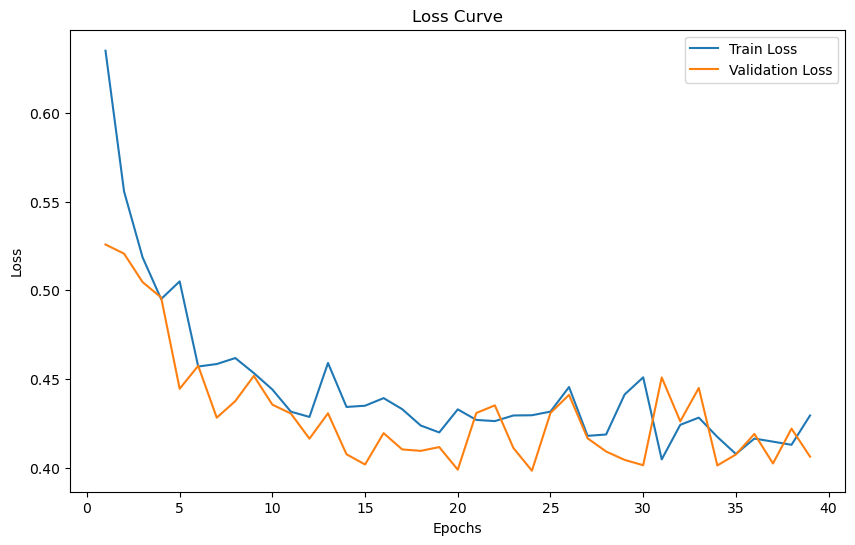

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize= (10,6))
plt.plot(range(1, len(train_loss)+1), train_loss, label= "Train Loss")
plt.plot(range(1, len(val_loss)+1), val_loss, label= "Validation Loss")
plt.title("Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show();

In [8]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch

def evaluate_multimodal_model(model, data_loader, device):
    model.eval()
    model.to(device)
    all_preds= []
    all_targets= []
    with torch.no_grad():
        for vid_inputs, aud_inputs, targets in data_loader:
            vid_inputs= vid_inputs.to(device)
            aud_inputs= aud_inputs.to(device)
            targets= targets.to(device, dtype=torch.long)
            logits= model(vid_inputs, aud_inputs)
            preds= torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    acc= accuracy_score(all_targets, all_preds)
    f1= f1_score(all_targets, all_preds, average='weighted')
    prec= precision_score(all_targets, all_preds, average='weighted')
    rec= recall_score(all_targets, all_preds, average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    return acc, prec, rec, f1

In [9]:
torch.manual_seed(0)

modelt= AVModel(video_net,audio_net)
state_dict= torch.load("AV_Fusion_Best.pth", weights_only=True)
modelt.load_state_dict(state_dict=state_dict)
modelt.eval()
test_loader= DataLoader(
    test_MultimodalDataset,
    batch_size= 2
)
acc, prec, rec, f1= evaluate_multimodal_model(modelt, test_loader, device)

Accuracy: 0.8750
Precision: 0.8796
Recall: 0.8750
F1-score: 0.8746
